In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import ruptures as rpt
from pathlib import Path
from collections import Counter
import json

In [3]:
lat_lon = pd.read_csv('bquxjob_4d97456_19d620bff51.csv')

Text(0, 0.5, 'Latitude')

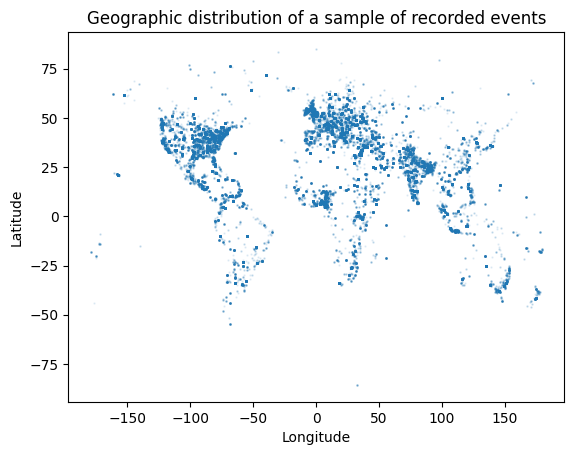

In [4]:
"""
sql query to get this result:
SELECT ActionGeo_Long, ActionGeo_Lat FROM `gdelt-bq.gdeltv2.events` 
WHERE ActionGeo_Long is NOT NULL
AND ActionGeo_Lat is NOT NULL LIMIT 100000;
"""
plt.scatter(lat_lon['ActionGeo_Long'], lat_lon['ActionGeo_Lat'], alpha=0.1, s=0.5)
plt.title('Geographic distribution of a sample of recorded events')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [5]:
split_locations = pd.read_csv('bquxjob_41c5f433_19d66658f81.csv')
split_locations.head()

,GKGRECORDID,DATE,locations,themes,counts
0,20251202161500-T941,20251202161500,"[4#Odessa, Odes'ka Oblast, Ukraine#UP#UP17#285...","[AFFECT,1355,SECURITY_SERVICES,140,SECURITY_SE...","[ARREST#2000##4#Odessa, Odes'ka Oblast, Ukrain..."
1,20251202161500-T955,20251202161500,"[1#Ukraine#UP#UP##49#32#UP#651,1#Ukraine#UP#UP...","[ARREST,444,ARREST,1471,ARREST,1736,CRISISLEX_...",[ARREST#2000000#c pledge#1#Ukraine#UP#UP#49#32...
2,20251202161500-T1979,20251202161500,[],"[WB_1979_NATURAL_RESOURCE_MANAGEMENT,766,WB_43...","[ARREST#2#following conviction#0#######57,SOC_..."
3,20251202161500-T2080,20251202161500,"[1#Romania#RO#RO##46#25#RO#36,1#Romania#RO#RO#...","[TAX_FNCACT_DEPUTY,603,TAX_FNCACT_HERO,341,EPU...",[KILL#10000000#Maple red#1#Romania#RO#RO#46#25...
4,20251202161500-T2089,20251202161500,"[4#Donghua, Sichuan, China#CH#CH32#13003#31.83...","[TAX_FNCACT_QUEEN,1133,URBAN,5933,TAX_FNCACT_W...",[KILL#6#time#1#Hong Kong#HK#HK#22.25#114.16666...


In [6]:
split_locations['counts'][3]

'[KILL#10000000#Maple red#1#Romania#RO#RO#46#25#RO#1051,CRISISLEX_CRISISLEXREC#10000000#Maple red#1#Romania#RO#RO#46#25#RO#1051,CRISISLEX_T02_INJURED#10000000#Maple red#1#Romania#RO#RO#46#25#RO#1051,CRISISLEX_T03_DEAD#10000000#Maple red#1#Romania#RO#RO#46#25#RO#1051,CRISISLEX_T03_DEAD#10000000#Maple red#1#Romania#RO#RO#46#25#RO#1051,]'

In [7]:
sample = pd.read_csv('sample.csv', low_memory=False)
sample

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1298342881,20250409,202504,2025,2025.2712,EDU,PROFESSOR,NaN,NaN,NaN,...,1,Italy,IT,IT,NaN,42.833333,12.833333,IT,20260409100000,https://www.nancyonnorwalk.com/norwalk-communi...
1,1298342882,20250409,202504,2025,2025.2712,GBR,UNITED KINGDOM,GBR,NaN,NaN,...,4,"English Channel, United Kingdom (general), Uni...",UK,UK00,154724,54.583300,-3.683330,-2595622,20260409100000,https://www.mirror.co.uk/news/uk-news/small-bo...
2,1298342883,20250409,202504,2025,2025.2712,ITA,ITALY,ITA,NaN,NaN,...,1,Italy,IT,IT,NaN,42.833333,12.833333,IT,20260409100000,https://www.nancyonnorwalk.com/norwalk-communi...
3,1298342884,20250409,202504,2025,2025.2712,MEDBUS,MEDIA,NaN,NaN,NaN,...,4,"Kathmandu, Bagmati, Nepal",NP,NP01,22353,27.716700,85.316700,-1022136,20260409100000,https://www.freepressjournal.in/world/former-n...
4,1298342885,20250409,202504,2025,2025.2712,MEDBUS,MEDIA,NaN,NaN,NaN,...,4,"Kathmandu, Bagmati, Nepal",NP,NP01,22353,27.716700,85.316700,-1022136,20260409100000,https://www.freepressjournal.in/world/former-n...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18106,1287233835,20260203,202602,2026,2026.0904,EDU,SCHOOL,NaN,NaN,NaN,...,4,"Montego, Saint James, Jamaica",JM,JM12,18429,18.471200,-77.918800,-3752832,20260203100000,https://www.jamaicaobserver.com/2026/02/03/alg...
18107,1287233837,20260203,202602,2026,2026.0904,EDU,SCHOOL,NaN,NaN,NaN,...,4,"Montego, Saint James, Jamaica",JM,JM12,18429,18.471200,-77.918800,-3752832,20260203100000,https://www.jamaicaobserver.com/2026/02/03/ape...
18108,1287234015,20260203,202602,2026,2026.0904,HLH,HOSPITAL,NaN,NaN,NaN,...,4,"Montego, Saint James, Jamaica",JM,JM12,18429,18.471200,-77.918800,-3752832,20260203100000,https://www.jamaicaobserver.com/2026/02/03/ape...
18109,1287234016,20260203,202602,2026,2026.0904,HLH,HOSPITAL,NaN,NaN,NaN,...,4,"Montego, Saint James, Jamaica",JM,JM12,18429,18.471200,-77.918800,-3752832,20260203100000,https://www.jamaicaobserver.com/2026/02/03/ape...


In [8]:
sample.groupby('QuadClass')['GoldsteinScale'].mean().reset_index() #1-4: Verbal Cooperation, Material Cooperation, Verbal Conflict, Material Conflict
sample.groupby('QuadClass')['AvgTone'].mean().reset_index()
sample.groupby('QuadClass')['NumArticles'].mean().reset_index()


,QuadClass,NumArticles
0,1,6.967998
1,2,7.185171
2,3,6.896942
3,4,7.113950


In [9]:
sample.sort_values('NumSources', ascending=False).head(10)[["GLOBALEVENTID", "NumArticles", "NumSources", "NumMentions", "AvgTone", "GoldsteinScale", "QuadClass", "SOURCEURL"]]

,GLOBALEVENTID,NumArticles,NumSources,NumMentions,AvgTone,GoldsteinScale,QuadClass,SOURCEURL
14294,1287142441,65,13,65,-0.972763,4.0,1,https://www.witneygazette.co.uk/news/national/...
8357,1287193488,30,10,30,-4.788550,0.0,1,https://www.theleader.com.au/story/9166386/tea...
8356,1287193238,10,10,10,-4.788550,0.0,1,https://www.theleader.com.au/story/9166386/tea...
14489,1287219794,100,10,100,-1.273885,4.0,1,https://www.yorkpress.co.uk/news/national/2581...
8355,1287193199,20,10,20,-4.788550,0.0,1,https://www.theleader.com.au/story/9166386/tea...
8358,1287193841,20,10,40,-4.788550,-10.0,4,https://www.theleader.com.au/story/9166386/tea...
14490,1287219813,100,10,100,-1.273885,-2.0,2,https://www.yorkpress.co.uk/news/national/2581...
462,1298343343,40,8,40,-6.391753,1.0,1,https://www.dumbartonreporter.co.uk/news/natio...
14284,1287164834,8,8,8,-0.626391,0.0,1,https://www.kentonline.co.uk/news/national/pol...
14281,1287164045,32,8,32,-0.626391,-2.0,3,https://www.kentonline.co.uk/news/national/pol...


In [10]:
split_locations.columns

Index(['GKGRECORDID', 'DATE', 'locations', 'themes', 'counts'], dtype='str')

In [11]:
gkg_sample = pd.read_csv('gkg_sample.csv', low_memory=False)
gkg_sample['V2Tone']

0      4.41176470588235,8.82352941176471,4.4117647058...
1      0.13550135501355,2.1680216802168,2.03252032520...
2      2.95081967213115,5.57377049180328,2.6229508196...
3      -0.192678227360308,2.3121387283237,2.504816955...
4      -1.61290322580645,0,1.61290322580645,1.6129032...
                             ...                        
736    0.660066006600661,3.63036303630363,2.970297029...
737    6.2992125984252,6.2992125984252,0,6.2992125984...
738    1.8796992481203,3.38345864661654,1.50375939849...
739    6.72268907563025,8.40336134453782,1.6806722689...
740    -1.48809523809524,4.16666666666667,5.654761904...
Name: V2Tone, Length: 741, dtype: str

In [12]:
poss = []
negs = []
pols = []
for i in range(len(gkg_sample)):
    tones = gkg_sample['V2Tone'].iloc[i]
    tones = tones.split(',')
    pos = float(tones[1])
    neg = float(tones[2])
    pol = float(tones[3])
    poss.append(pos)
    negs.append(neg)
    pols.append(pol)

gkg_sample['V2Tone_pos'] = poss
gkg_sample['V2Tone_neg'] = negs
gkg_sample['V2Tone_pol'] = pols

In [13]:
gkg_sample.sort_values('V2Tone_neg', ascending=False)['DocumentIdentifier'].iloc[0]

'https://fijisun.com.fj:443/news/courts-and-law/bail-refused-for-man-charged-in-dr-leighley-darlings-death'

In [14]:
#float(gkg_sample['V2Tone'][0][1])

In [15]:
gkg_sample 

,GKGRECORDID,DATE,SourceCollectionIdentifier,SourceCommonName,DocumentIdentifier,Counts,V2Counts,Themes,V2Themes,Locations,...,SocialImageEmbeds,SocialVideoEmbeds,Quotations,AllNames,Amounts,TranslationInfo,Extras,V2Tone_pos,V2Tone_neg,V2Tone_pol
0,20260410041500-672,20260410041500,1,indiatimes.com,https://economictimes.indiatimes.com/markets/s...,NaN,NaN,ECON_STOCKMARKET;TAX_ETHNICITY;TAX_ETHNICITY_I...,"TAX_ECON_PRICE,245;TAX_ECON_PRICE,413;WB_698_T...",1#Iran#IR#IR#32#53#IR,...,NaN,NaN,NaN,"Sensex Today,13;Stock Market Live Updates,53;W...","50,| Stock Market Live,19;",NaN,<PAGE_ALTURL_AMP>https://m.economictimes.com/m...,8.823529,4.411765,13.235294
1,20260410041500-194,20260410041500,1,hppr.org,https://www.hppr.org/npr-news/2026-04-09/why-p...,NaN,NaN,NaN,NaN,"3#Denver, Colorado, United States#US#USCO#39.7...",...,NaN,NaN,NaN,"Indicator From Planet Money,148;Ricky Mulvey,1...","10,can be minuscule,495;800,bucks when it grad...",NaN,<PAGE_ALTURL_AMP>https://www.hppr.org/npr-news...,2.168022,2.032520,4.200542
2,20260410041500-631,20260410041500,1,wflx.com,https://www.wflx.com/2026/04/09/florida-foster...,NaN,NaN,CRISISLEX_CRISISLEXREC;TAX_FNCACT;TAX_FNCACT_C...,"SHORTAGE,673;TAX_FNCACT_EXECUTIVE,1462;TAX_FNC...","3#Palm Beach County, Florida, United States#US...",...,NaN,NaN,NaN,"Palm Beach,379;Florida Department,410;Fosterin...","6,girls sharing one bathroom,445;5,months,2824;",NaN,<PAGE_ALTURL_AMP>https://www.wflx.com/2026/04/...,5.573770,2.622951,8.196721
3,20260410041500-488,20260410041500,1,wflx.com,https://www.wflx.com/2026/04/10/palm-beach-cou...,NaN,NaN,SOC_POINTSOFINTEREST;SOC_POINTSOFINTEREST_FIRE...,"SOC_POINTSOFINTEREST_FIRE_STATION,66;SOC_POINT...",NaN,...,NaN,NaN,NaN,"Palm Beach County Fire Rescue,30;Saddle View E...","6,firefighters staffing an Advanced,709;70,is ...",NaN,<PAGE_ALTURL_AMP>https://www.wflx.com/2026/04/...,2.312139,2.504817,4.816956
4,20260410041500-729,20260410041500,1,rbr.com,https://rbr.com/another-meme-stock-surge-comes...,NaN,NaN,WB_678_DIGITAL_GOVERNMENT;WB_694_BROADCAST_AND...,"ECON_STOCKMARKET,174;ECON_STOCKMARKET,237;WB_6...",NaN,...,NaN,NaN,NaN,"Beasley Media,141",NaN,NaN,<PAGE_AUTHORS>Adam Jacobson</PAGE_AUTHORS><PAG...,0.000000,1.612903,1.612903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,20260410041500-48,20260410041500,1,allkpop.com,https://www.allkpop.com/article/2026/04/2pms-h...,NaN,NaN,TAX_FNCACT;TAX_FNCACT_ACTOR;TAX_WORLDFISH;TAX_...,"WB_1467_EDUCATION_FOR_ALL,656;WB_470_EDUCATION...","4#Seoul, Soul-T'ukpyolsi, South Korea#KS#KS11#...",...,NaN,https://youtube.com/user/allkpop?sub_confirmat...,NaN,"Hwang Chansung,40;Bloodhound Season,122;Yeongd...","2000000,member,4;2,follows Geon Woo,237;2,bega...",NaN,<PAGE_LINKS>https://www.allkpop.com/artisttag/...,3.630363,2.970297,6.600660
737,20260410041500-246,20260410041500,1,allkpop.com,https://www.allkpop.com/article/2026/04/hyuna-...,NaN,NaN,TAX_FNCACT;TAX_FNCACT_ARTIST;,"TAX_FNCACT_ARTIST,321;",1#United States#US#US#39.828175#-98.5795#US,...,NaN,https://youtube.com/user/allkpop?sub_confirmat...,NaN,"Jackson Wang,674","5,months,372;2,WORLD TOUR,528;",NaN,<PAGE_LINKS>https://www.allkpop.com/artisttag/...,6.299213,0.000000,6.299213
738,20260410041500-290,20260410041500,1,allkpop.com,https://www.allkpop.com/article/2026/04/kang-d...,NaN,NaN,TAX_FNCACT;TAX_FNCACT_COED;MANMADE_DISASTER_IM...,"TAX_FNCACT_LEADER,531;TAX_FNCACT_OFFICIAL,883;...","4#Kang Dong, Cholla-Namdo, South Korea#KS#KS16...",...,https://instagram.com/p/DW7bOoMAXmJ;,https://youtube.com/user/allkpop?sub_confirmat...,NaN,"Wild Thing',88;Son Jae,113;Hwang Hyun Woo,522;...",NaN,NaN,<PAGE_LINKS>https://www.allkpop.com/artisttag/...,3.383459,1.503759,4.887218
739,20260410041500-180,20260410041500,1,allkpop.com,https://www.allkpop.com/article/2026/04/naze-d...,NaN,NaN,NaN,NaN,"1#Japan#JA#JA#36#138#JA;4#Yuya, Yamaguchi, Jap...",...,NaN,https://youtube.com/user/allkpop?sub_confirmat...,NaN,"Kim Kun,221;Park Eun Young,691",NaN,NaN,<

In [16]:
merged_sample = pd.read_csv('three_tables_merged.csv', low_memory=False)

In [17]:
merged_sample[merged_sample['Actor2Geo_CountryCode'].isna()]

,GKGRECORDID,DATE,SourceCommonName,V2Tone,MentionDocLen,Amounts,GoldsteinScale,QuadClass,ActionGeo_CountryCode,Actor1Geo_CountryCode,Actor2Geo_CountryCode
48,20231012123000-128,20231012123000,globalsecurity.org,"-0.606060606060606,2.72727272727273,3.33333333...",2085,"50,countries,504;",4.5,1,UP,UP,NaN
49,20240518030000-227,20240518030000,globalsecurity.org,"-3.67441294561382,2.39688526584743,6.071298211...",50269,"2,organizations,950;300,aid trucks,4371;22,Ara...",-0.1,1,IS,IS,NaN
50,20180302041500-2422,20180302041500,globalsecurity.org,"-2.2271714922049,3.11804008908686,5.3452115812...",2665,"1000000,people,768;",-0.1,1,SU,US,NaN
51,20230620094500-1292,20230620094500,globalsecurity.org,"-7.58620689655172,1.83908045977011,9.425287356...",2687,"6000000000,is needed this year,950;470000000,d...",9.0,2,SU,SU,NaN
52,20240712123000-113,20240712123000,globalsecurity.org,"2.33804188991719,3.50706283487579,1.1690209449...",12350,"2,countries push forward major,2993;2,countrie...",4.5,1,RP,RP,NaN
...,...,...,...,...,...,...,...,...,...,...,...
17684,20250128151500-1154,20250128151500,globalsecurity.org,"-8.87573964497041,0.394477317554241,9.27021696...",3010,"2,people after raiding their,863;5,Palestinian...",-10.0,4,WE,WE,NaN
17685,20231221034500-230,20231221034500,globalsecurity.org,"-6.09452736318408,1.49253731343284,7.587064676...",10785,"5,attacks launched by assault,5985;40,Ukrainia...",-10.0,4,RS,RS,NaN
17686,20181114071500-393,20181114071500,globalsecurity.org,"1.84049079754601,4.9079754601227,3.06748466257...",2020,"2,went into meetings designed,311;2,nations cl...",-10.0,4,QA,QA,NaN
17687,20241006020000-596,20241006020000,globalsecurity.org,"-6.77804295942721,1.05011933174224,7.828162291...",13554,"2,key fronts of Zaporizhzhia,1353;147,combat c...",-10.0,4,UP,RS,NaN


In [18]:
poss, negs, pols = [], [], []

for i in range(len(merged_sample)):
    tones = merged_sample['V2Tone'].iloc[i]
    tones = tones.split(',')
    pos = float(tones[1])
    neg = float(tones[2])
    pol = float(tones[3])
    poss.append(pos)
    negs.append(neg)
    pols.append(pol)

merged_sample['V2Tone_pos'] = poss
merged_sample['V2Tone_neg'] = negs
merged_sample['V2Tone_tone'] = merged_sample['V2Tone_pos'] - merged_sample['V2Tone_neg']
merged_sample['V2Tone_pol'] = pols

In [19]:
# group by action loaction and quad class, then get the average goldstein scale for each group, also display count of mentions in each group
merged_sample['MentionDocLen_log'] = np.log(merged_sample['MentionDocLen'] + 1)
merged_sample.groupby(['ActionGeo_CountryCode', 'QuadClass'])[
    ['GoldsteinScale', 'MentionDocLen_log']
].agg(['count', 'mean']).sort_values(('MentionDocLen_log', 'mean'), ascending=False).reset_index()

ActionGeo_CountryCode QuadClass GoldsteinScale            \
                                             count      mean   
0                      NP         2              2  8.750000   
1                      CU         2              5  9.000000   
2                      HO         1              1  3.200000   
3                      FO         2              2  6.400000   
4                      JA         3              1 -7.500000   
..                    ...       ...            ...       ...   
543                    AO         1              1  3.200000   
544                    TD         1              9  1.922222   
545                    PA         1              3  4.500000   
546                    AL         2              1  8.500000   
547                    FI         3              1 -5.800000   

    MentionDocLen_log             
                count       mean  
0                   2  11.372950  
1                   5  10.951747  
2                   1  10.846323  
3                   2  10.417927  
4                   1  10.391853  
..                ...        ...  
543                 1   7.080026  
544                 9   6.998596  
545                 3   6.958448  
546                 1   6.952729  
547                 1   6.579251  

[548 rows x 6 columns]

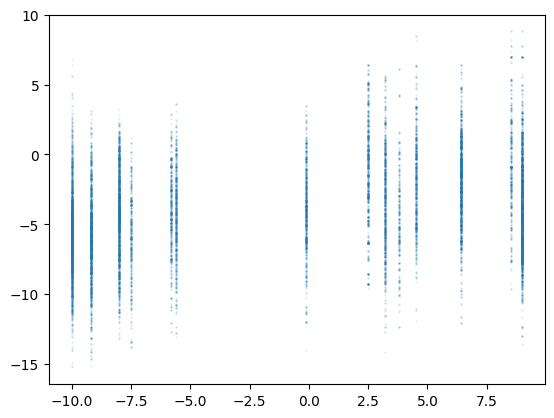

In [20]:
plt.scatter(merged_sample['GoldsteinScale'], merged_sample['V2Tone_tone'], alpha=0.1, s=0.5)

In [21]:
df = merged_sample.groupby(['ActionGeo_CountryCode', 'QuadClass'])[
    ['GoldsteinScale', 'MentionDocLen_log']
].agg(['count', 'mean'])

df.columns = ['_'.join(col) for col in df.columns]

df = df[df['GoldsteinScale_count'] > 1] \
       .sort_values('MentionDocLen_log_mean', ascending=False) \
       .reset_index()

df[df['ActionGeo_CountryCode'] == 'LE']


,ActionGeo_CountryCode,QuadClass,GoldsteinScale_count,GoldsteinScale_mean,MentionDocLen_log_count,MentionDocLen_log_mean
209,LE,4,191,-9.480628,191,8.388416
236,LE,2,95,8.584211,95,8.339019
320,LE,1,78,2.687179,78,8.155568
362,LE,3,28,-6.346429,28,8.049118


In [22]:
df = merged_sample.groupby(['ActionGeo_CountryCode'])[
    ['GoldsteinScale', 'MentionDocLen_log']
].agg(['count', 'mean'])

df.columns = ['_'.join(col) for col in df.columns]

df[df['GoldsteinScale_count'] > 20] \
       .sort_values('MentionDocLen_log_mean', ascending=False) \
       .reset_index()

df.sort_values('GoldsteinScale_count', ascending=False).head(20).reset_index()

,ActionGeo_CountryCode,GoldsteinScale_count,GoldsteinScale_mean,MentionDocLen_log_count,MentionDocLen_log_mean
0,IS,4213,-3.403608,4213,8.446281
1,US,1559,-0.922579,1559,8.402004
2,RS,1359,-1.461369,1359,8.845125
3,UP,898,-0.785412,898,9.003150
4,AF,694,-0.633862,694,8.084357
5,IR,652,-0.199540,652,8.401311
6,CH,440,1.733864,440,8.530592
7,SU,426,-1.903521,426,8.470921
8,YM,414,-1.191787,414,8.081690
9,LE,392,-2.457653,392,8.305877


In [23]:
merged_sample.groupby(['QuadClass'])['GoldsteinScale'].mean()

QuadClass
1    2.611061
2    8.044105
3   -6.578202
4   -8.838875
Name: GoldsteinScale, dtype: float64

In [24]:
merged_sample[(merged_sample['ActionGeo_CountryCode'] != merged_sample['Actor2Geo_CountryCode']) & (merged_sample['ActionGeo_CountryCode'] != merged_sample['Actor1Geo_CountryCode'])]

,GKGRECORDID,DATE,SourceCommonName,V2Tone,MentionDocLen,Amounts,GoldsteinScale,QuadClass,ActionGeo_CountryCode,Actor1Geo_CountryCode,Actor2Geo_CountryCode,V2Tone_pos,V2Tone_neg,V2Tone_tone,V2Tone_pol,MentionDocLen_log
12,20250601040000-134,20250601040000,globalsecurity.org,"-7.04225352112676,1.92061459667093,8.962868117...",5189,"141,combat encounters,1301;2,missile,1343;8,ai...",9.0,2,RS,UP,UP,1.920615,8.962868,-7.042254,10.883483,8.554489
18,20230613113000-1692,20230613113000,globalsecurity.org,"-5.10948905109489,3.46715328467153,8.576642335...",3458,NaN,-9.2,4,US,BU,BU,3.467153,8.576642,-5.109489,12.043796,8.148735
27,20250802123000-864,20250802123000,globalsecurity.org,"1.22699386503067,2.45398773006135,1.2269938650...",1921,"9000000000,dollars of goods,1137;",6.4,2,NZ,US,KS,2.453988,1.226994,1.226994,3.680982,7.561122
28,20191203053000-1184,20191203053000,globalsecurity.org,"-2.65700483091787,1.44927536231884,4.106280193...",2453,"2,must rather complement each,1508;",6.4,2,US,SP,IT,1.449275,4.106280,-2.657005,5.555556,7.805475
32,20260120133000-725,20260120133000,globalsecurity.org,"-0.826446280991736,1.65289256198347,2.47933884...",1588,"2,senior Canadian government officials,262;",9.0,2,FI,GL,NL,1.652893,2.479339,-0.826446,4.132231,7.370860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18204,20250526043000-716,20250526043000,globalsecurity.org,"-2.4390243902439,3.2520325203252,5.69105691056...",799,NaN,-10.0,4,YM,IS,IS,3.252033,5.691057,-2.439024,8.943089,6.684612
18231,20200724054500-70,20200724054500,globalsecurity.org,"-1.50943396226415,2.26415094339623,3.773584905...",1556,"2,roadside bombs,173;2,weeks,225;2,explosive d...",-10.0,4,IR,US,IZ,2.264151,3.773585,-1.509434,6.037736,7.350516
18232,20230722124500-321,20230722124500,globalsecurity.org,"-3.77358490566038,2.51572327044025,6.289308176...",4000,"2,countries,255;2,countries,359;2,wars over Na...",-10.0,4,AM,AJ,AJ,2.515723,6.289308,-3.773585,8.805031,8.294300
18238,20231209130000-391,20231209130000,globalsecurity.org,"-9.93975903614458,1.20481927710843,11.14457831...",2013,"4,Palestinians across West Bank,18;2,teenagers...",-10.0,4,IS,GZ,WE,1.204819,11.144578,-9.939759,12.349398,7.607878


### Get list of all distinct country codes

In [25]:
#cc = pd.read_csv('distinct_country_codes.csv')
#list(cc['ActionGeo_CountryCode'])

In [26]:
timelines_1f = pd.read_csv('all_countries_timelines_1f.csv')
timelines_1f.head()

,BinnedDate,AA,AC,AE,AF,AG,AJ,AL,AM,AN,...,WE,WF,WI,WQ,WS,WZ,YI,YM,ZA,ZI
0,2016.0,219,478,17759,46155,11309,7312,5260,7767,304,...,12293,2,419,0,579,623,211,36813,5220,10695
1,2016.1,437,1532,36315,95548,23246,26391,17347,27785,1257,...,25495,1,1470,5,2021,1989,543,51644,14839,27819
2,2016.2,654,1055,34093,77058,29143,28595,20423,31098,1098,...,18956,0,3706,16,2576,1738,1352,59712,14813,26906
3,2016.3,560,972,31409,84800,25080,81597,27728,82678,1312,...,14709,0,2035,2,2783,1959,548,68666,14420,23118
4,2016.4,883,855,33930,126039,24632,41880,38440,50716,1221,...,16705,0,1378,1,3224,2133,668,65786,12296,25788


In [27]:
timelines_1f['UK']

0      167326
1      439155
2      385240
3      431570
4      462407
        ...  
99     231610
100    175060
101    266876
102    252607
103    105724
Name: UK, Length: 104, dtype: int64

BQ: 0.2403846153846154
BS: 0.0673076923076923
BV: 1.4230769230769231
CQ: 55.22115384615385
CR: 0.18269230769230768
DQ: 0.7596153846153846
EU: 0.09615384615384616
FK: 45.40384615384615
FQ: 0.9423076923076923
GO: 0.038461538461538464
HQ: 9.673076923076923
IM: 62.69230769230769
IO: 75.77884615384616
IP: 0.38461538461538464
JN: 1.8557692307692308
JQ: 2.730769230769231
JU: 0.009615384615384616
KQ: 0.4423076923076923
KT: 84.875
LQ: 1.7596153846153846
MQ: 0.18269230769230768
NE: 84.27884615384616
NF: 17.932692307692307
NT: 14.75
PC: 49.125
PF: 39.31730769230769
PG: 57.81730769230769
SB: 13.057692307692308
SH: 72.67307692307692
TE: 0.47115384615384615
TL: 41.83653846153846
WF: 1.4230769230769231
WQ: 11.173076923076923


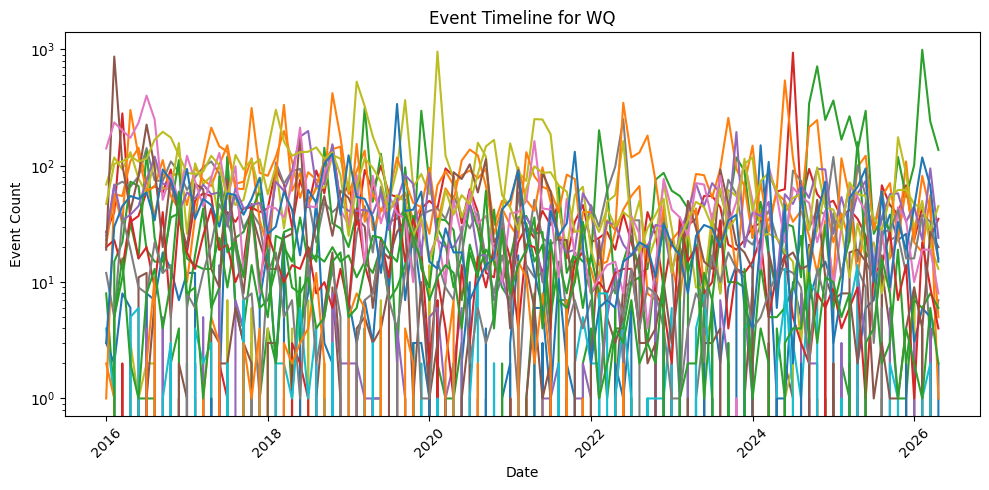

In [28]:
plt.figure(figsize=(10, 5))
for column in timelines_1f.columns[1:]:
    if timelines_1f[column].mean() < 100:
        sns.lineplot(data=timelines_1f, x='BinnedDate', y=column)
        plt.title(f'Event Timeline for {column}')
        plt.xlabel('Date')
        plt.ylabel('Event Count')
        plt.yscale('log')
        plt.xticks(rotation=45)
        plt.tight_layout()
        print(f'{column}: {timelines_1f[column].mean()}')
plt.show()

In [29]:
merged_sample 

,GKGRECORDID,DATE,SourceCommonName,V2Tone,MentionDocLen,Amounts,GoldsteinScale,QuadClass,ActionGeo_CountryCode,Actor1Geo_CountryCode,Actor2Geo_CountryCode,V2Tone_pos,V2Tone_neg,V2Tone_tone,V2Tone_pol,MentionDocLen_log
0,20231115041500-1026,20231115041500,globalsecurity.org,"-4.55369736046746,1.86379206125327,6.417489421...",61336,"200,Israelis killed on the,206;3000000,people,...",-5.8,3,IR,IR,IR,1.863792,6.417489,-4.553697,8.281281,11.024139
1,20190702001500-448,20190702001500,globalsecurity.org,"-4.05750057964294,2.01715743102249,6.074658010...",14722,"3,fronts,2896;2,Saudi ships off Fujairah,4512;...",6.4,2,IR,IR,US,2.017157,6.074658,-4.057501,8.091815,9.597166
2,20231218103000-367,20231218103000,globalsecurity.org,"-10.0456621004566,0.45662100456621,10.50228310...",1383,"5,Palestinians killed,1;5,Palestinians were ki...",-9.2,4,IS,IS,WE,0.456621,10.502283,-10.045662,10.958904,7.232733
3,20231218103000-367,20231218103000,globalsecurity.org,"-10.0456621004566,0.45662100456621,10.50228310...",1383,"5,Palestinians killed,1;5,Palestinians were ki...",-9.2,4,WE,IS,WE,0.456621,10.502283,-10.045662,10.958904,7.232733
4,20171213050000-460,20171213050000,globalsecurity.org,"-1.26422250316056,4.17193426042984,5.436156763...",4816,"14,Tanzanian,74;5,Congolese soldiers,90;600000...",9.0,2,LI,NaN,LI,4.171934,5.436157,-1.264223,9.608091,8.479907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18260,20200102054500-811,20200102054500,globalsecurity.org,"-3.52941176470588,1.17647058823529,4.705882352...",1576,"100,of paratroopers,1100;",-10.0,4,IZ,IZ,IZ,1.176471,4.705882,-3.529412,5.882353,7.363280
18261,20251219113000-1352,20251219113000,globalsecurity.org,"-3.48749052312358,3.03260045489007,6.520090978...",8902,"200,international,243;12,of international NGOs...",-10.0,4,SU,NaN,SU,3.032600,6.520091,-3.487491,9.552691,9.094144
18262,20230406013000-1697,20230406013000,globalsecurity.org,"-4.59110473457676,1.506456241033,6.09756097560...",9191,"35,attacks,2203;2,Georgian mercenaries who fou...",-10.0,4,RS,UP,RS,1.506456,6.097561,-4.591105,7.604017,9.126089
18263,20260315024500-42,20260315024500,globalsecurity.org,"-8.26771653543307,2.0997375328084,10.367454068...",5093,"117,combat clashes,1311;68,airstrikes,1477;188...",-10.0,4,RS,RS,UP,2.099738,10.367454,-8.267717,12.467192,8.535819


In [30]:
tensor_data = merged_sample[['GoldsteinScale', 'V2Tone_tone', 'V2Tone_pol', 'MentionDocLen_log', 'QuadClass']]
tensor_data

,GoldsteinScale,V2Tone_tone,V2Tone_pol,MentionDocLen_log,QuadClass
0,-5.8,-4.553697,8.281281,11.024139,3
1,6.4,-4.057501,8.091815,9.597166,2
2,-9.2,-10.045662,10.958904,7.232733,4
3,-9.2,-10.045662,10.958904,7.232733,4
4,9.0,-1.264223,9.608091,8.479907,2
...,...,...,...,...,...
18260,-10.0,-3.529412,5.882353,7.363280,4
18261,-10.0,-3.487491,9.552691,9.094144,4
18262,-10.0,-4.591105,7.604017,9.126089,4
18263,-10.0,-8.267717,12.467192,8.535819,4


In [31]:
complete_sample = pd.read_csv('complete_sample.csv', low_memory=False)

In [32]:
complete_sample['Offset'] = complete_sample['MentionTimeDate'] - complete_sample['EventTimeDate']
complete_sample 

,FractionDate,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Lat,ActionGeo_Long,EventTimeDate,MentionTimeDate,SentenceID,MentionDocLen,MentionDocTone,Offset
0,2024.1068,1,1.9,11,1,11,-5.601621,25.7743,-80.19370,20240209003000,20240216123000,37,22411,0.810509,7120000
1,2019.1014,2,10.0,13,1,9,-3.560209,36.5282,37.95500,20190207001500,20190207073000,19,13348,1.070473,71500
2,2024.6603,4,-10.0,14,1,10,-6.093190,31.6667,34.91670,20240901083000,20240901083000,1,1668,-6.093190,0
3,2019.4603,1,0.0,30,1,30,-0.091130,47.0000,8.00000,20190618143000,20190618214500,4,6557,-0.090009,71500
4,2023.5781,4,-5.6,9,1,9,-3.720930,13.5167,2.11667,20230801141500,20230801141500,2,1368,-3.720930,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64533,2017.7644,1,1.0,1,1,1,5.084746,44.4333,26.10000,20171009204500,20171009233000,2,1887,4.081633,28500
64534,2024.6466,4,-10.0,1,1,1,-5.489260,31.4167,34.33330,20240826111500,20240826111500,21,5292,-5.489260,0
64535,2025.9479,4,-10.0,1,1,1,-7.501821,47.7535,35.13790,20251216044500,20251216044500,34,9717,-7.501821,0
64536,2026.0849,1,5.2,1,1,1,2.220704,33.8191,-80.90660,20260131134500,20260131134500,54,21587,2.220704,0


In [33]:
complete_sample[complete_sample['QuadClass'] == 4][['GoldsteinScale', 'NumMentions', 'MentionDocTone', 'MentionDocLen', 'Offset']].corr()

,GoldsteinScale,NumMentions,MentionDocTone,MentionDocLen,Offset
GoldsteinScale,1.000000,-0.094496,0.173664,-0.017257,0.001776
NumMentions,-0.094496,1.000000,-0.069117,-0.056933,0.009786
MentionDocTone,0.173664,-0.069117,1.000000,0.180327,-0.006984
MentionDocLen,-0.017257,-0.056933,0.180327,1.000000,-0.008865
Offset,0.001776,0.009786,-0.006984,-0.008865,1.000000


In [34]:
complete_sample

,FractionDate,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_Lat,ActionGeo_Long,EventTimeDate,MentionTimeDate,SentenceID,MentionDocLen,MentionDocTone,Offset
0,2024.1068,1,1.9,11,1,11,-5.601621,25.7743,-80.19370,20240209003000,20240216123000,37,22411,0.810509,7120000
1,2019.1014,2,10.0,13,1,9,-3.560209,36.5282,37.95500,20190207001500,20190207073000,19,13348,1.070473,71500
2,2024.6603,4,-10.0,14,1,10,-6.093190,31.6667,34.91670,20240901083000,20240901083000,1,1668,-6.093190,0
3,2019.4603,1,0.0,30,1,30,-0.091130,47.0000,8.00000,20190618143000,20190618214500,4,6557,-0.090009,71500
4,2023.5781,4,-5.6,9,1,9,-3.720930,13.5167,2.11667,20230801141500,20230801141500,2,1368,-3.720930,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64533,2017.7644,1,1.0,1,1,1,5.084746,44.4333,26.10000,20171009204500,20171009233000,2,1887,4.081633,28500
64534,2024.6466,4,-10.0,1,1,1,-5.489260,31.4167,34.33330,20240826111500,20240826111500,21,5292,-5.489260,0
64535,2025.9479,4,-10.0,1,1,1,-7.501821,47.7535,35.13790,20251216044500,20251216044500,34,9717,-7.501821,0
64536,2026.0849,1,5.2,1,1,1,2.220704,33.8191,-80.90660,20260131134500,20260131134500,54,21587,2.220704,0


In [35]:
pd.read_csv('three_tables_merged.csv', low_memory=False)

,GKGRECORDID,DATE,SourceCommonName,V2Tone,MentionDocLen,Amounts,GoldsteinScale,QuadClass,ActionGeo_CountryCode,Actor1Geo_CountryCode,Actor2Geo_CountryCode
0,20231115041500-1026,20231115041500,globalsecurity.org,"-4.55369736046746,1.86379206125327,6.417489421...",61336,"200,Israelis killed on the,206;3000000,people,...",-5.8,3,IR,IR,IR
1,20190702001500-448,20190702001500,globalsecurity.org,"-4.05750057964294,2.01715743102249,6.074658010...",14722,"3,fronts,2896;2,Saudi ships off Fujairah,4512;...",6.4,2,IR,IR,US
2,20231218103000-367,20231218103000,globalsecurity.org,"-10.0456621004566,0.45662100456621,10.50228310...",1383,"5,Palestinians killed,1;5,Palestinians were ki...",-9.2,4,IS,IS,WE
3,20231218103000-367,20231218103000,globalsecurity.org,"-10.0456621004566,0.45662100456621,10.50228310...",1383,"5,Palestinians killed,1;5,Palestinians were ki...",-9.2,4,WE,IS,WE
4,20171213050000-460,20171213050000,globalsecurity.org,"-1.26422250316056,4.17193426042984,5.436156763...",4816,"14,Tanzanian,74;5,Congolese soldiers,90;600000...",9.0,2,LI,NaN,LI
...,...,...,...,...,...,...,...,...,...,...,...
18260,20200102054500-811,20200102054500,globalsecurity.org,"-3.52941176470588,1.17647058823529,4.705882352...",1576,"100,of paratroopers,1100;",-10.0,4,IZ,IZ,IZ
18261,20251219113000-1352,20251219113000,globalsecurity.org,"-3.48749052312358,3.03260045489007,6.520090978...",8902,"200,international,243;12,of international NGOs...",-10.0,4,SU,NaN,SU
18262,20230406013000-1697,20230406013000,globalsecurity.org,"-4.59110473457676,1.506456241033,6.09756097560...",9191,"35,attacks,2203;2,Georgian mercenaries who fou...",-10.0,4,RS,UP,RS
18263,20260315024500-42,20260315024500,globalsecurity.org,"-8.26771653543307,2.0997375328084,10.367454068...",5093,"117,combat clashes,1311;68,airstrikes,1477;188...",-10.0,4,RS,RS,UP


     mentions Actor1Code Actor2Code       f0_
13      16184        USA        GOV -1.911972
14      16065        GOV        USA -2.652608
20      13344        RUS        UKR -4.012651
22      11422        UKR        RUS -3.898100
23      11397        ISR        PSE -6.459381
..        ...        ...        ...       ...
288      1016        UKR        GOV -2.469584
290      1011        EDU        GBR -2.292579
291      1011        JUD        CRM -6.891171
292      1007        UAF        ISR -7.249224
293      1001        MDA        RUS -4.344422

[159 rows x 4 columns]


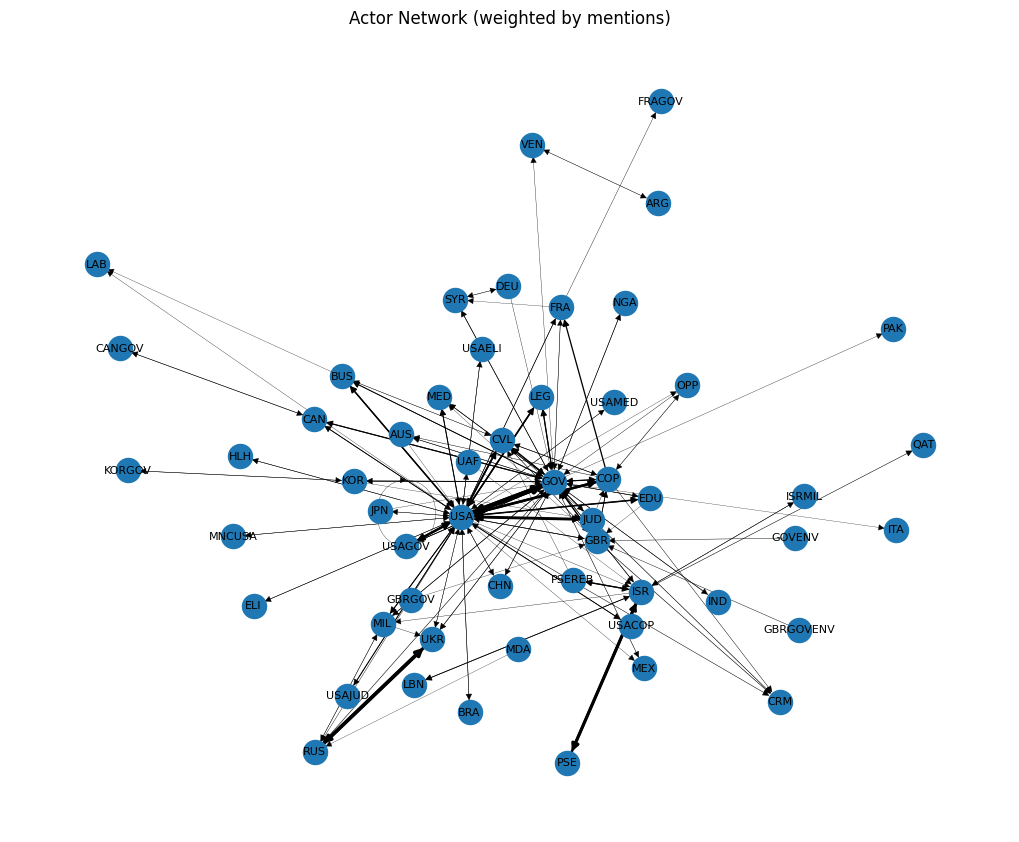

In [36]:
acs = pd.read_csv('graphs_actorcode.csv')
acs = acs.dropna()
acs = acs[acs['mentions'] >= 1000]
print(acs)

G = nx.from_pandas_edgelist(
    acs,
    source='Actor1Code',
    target='Actor2Code',
    edge_attr='mentions',
    create_using=nx.DiGraph()  # use Graph() if undirected
)

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, k=0.5)

# Edge weights → thickness
weights = [G[u][v]['mentions'] for u, v in G.edges()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300,
    font_size=8,
    width=[w * 0.0002 for w in weights]  # scale weights
)

plt.title("Actor Network (weighted by mentions)")
plt.show()

     mentions Actor1CountryCode Actor2CountryCode       f0_
4       48297               USA               USA -3.170613
10      20565               ISR               PSE -6.577430
15      16867               PSE               ISR -6.729180
16      15594               RUS               UKR -4.001502
19      14599               UKR               RUS -3.922913
..        ...               ...               ...       ...
622       202               ESP               FRA  0.337588
623       202               USA               WSM  1.586967
624       201               EUR               IRN -0.740710
626       200               EUR               POL -0.254383
627       200               IRQ               USA -3.265583

[369 rows x 4 columns]


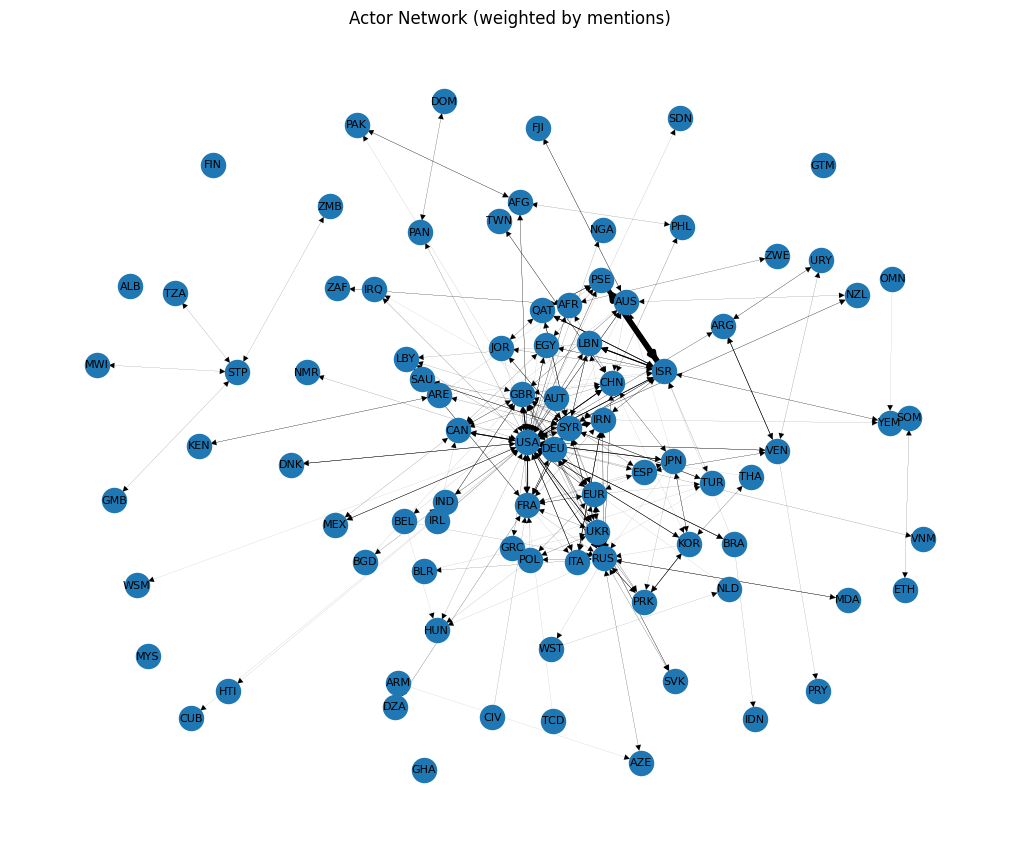

In [37]:
ccs = pd.read_csv('graphs_countrycode.csv')
ccs = ccs.dropna()
ccs = ccs[ccs['mentions'] >= 200]
print(ccs)

G = nx.from_pandas_edgelist(
    ccs,
    source='Actor1CountryCode',
    target='Actor2CountryCode',
    edge_attr='mentions',
    create_using=nx.DiGraph()  # use Graph() if undirected
)

#remove self loops:
G.remove_edges_from(nx.selfloop_edges(G))
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5)
# Edge weights → thickness
weights = [G[u][v]['mentions'] for u, v in G.edges()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300,
    font_size=8,
    width=[w * 0.0002 for w in weights]  # scale weights
)

plt.title("Actor Network (weighted by mentions)")
plt.show()

In [38]:
ccs

,mentions,Actor1CountryCode,Actor2CountryCode,f0_
4,48297,USA,USA,-3.170613
10,20565,ISR,PSE,-6.577430
15,16867,PSE,ISR,-6.729180
16,15594,RUS,UKR,-4.001502
19,14599,UKR,RUS,-3.922913
...,...,...,...,...
622,202,ESP,FRA,0.337588
623,202,USA,WSM,1.586967
624,201,EUR,IRN,-0.740710
626,200,EUR,POL,-0.254383


# Using ruptures as baseline model on the existing country pair timelines

Different models:
- l1: robust mean shifts
- l2: gaussian mean shifts
- rbf: non-parametric shifts in distribution (good for multivariate)
- linear: regression change points
- normal: mean + variance shift
- ar: autoregressive model shifts

0, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\AFR_GOV_data.csv
20, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\CANGOV_CAN_data.csv
40, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\CRM_COP_data.csv
60, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\EDU_USAEDU_data.csv
80, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\GOV_AUS_data.csv
100, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\GOV_MIL_data.csv
120, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\ISR_USA_data.csv
140, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\MED_CVL_data.csv
160, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\PTY_GOV_data.csv
180, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\USA_FRA_data.csv
200, processed D:\gdelt_data\input_datasets\weekly_pw_filtered_features\USA_USABUS_data.csv
220, processed D:\

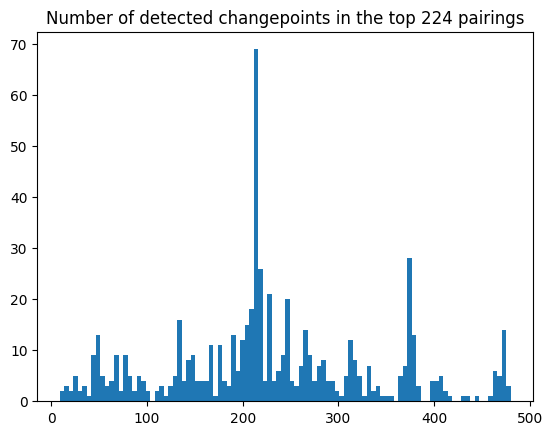

2020-02-24 00:00:00
2020-03-16 00:00:00
2023-03-13 00:00:00
2020-05-18 00:00:00
2020-09-21 00:00:00
2019-12-02 00:00:00
2020-02-03 00:00:00
2020-01-13 00:00:00
2022-01-17 00:00:00
2021-01-25 00:00:00


In [ ]:
all_change_points = []
raw_scores = []

data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
counter = 0
for csv_file in data_dir.glob("*.csv"):

    df = pd.read_csv(csv_file)

    ws_pp = df.copy()

    X = np.column_stack([
        ws_pp['Relative_mentions'], #Relative mentions or mentions
        ws_pp['events'],
        ws_pp['avg_sentenceid'],
        ws_pp['avg_a1co'],
        ws_pp['avg_a2co'],
        ws_pp['avg_actco'],
        ws_pp['avg_raw_text'],
        ws_pp['avg_root_event'],
        ws_pp['avg_len'],
        ws_pp['avg_goldstein'],
        ws_pp['avg_tone'],
        ws_pp['avg_confidence'],
        ws_pp['avg_lat1'],
        ws_pp['avg_lon1'],
        ws_pp['avg_lat2'],
        ws_pp['avg_lon2'],
        ws_pp['avg_lata'],
        ws_pp['avg_lona'],
        ws_pp['total_num_mentions'],
        ws_pp['total_num_sources'],
        ws_pp['total_num_articles'],
    ])

    X = (X - X.mean(axis=0)) / X.std(axis=0)

    # Choose model (good default: "rbf" for multivariate)
    model = "rbf"
    algo = rpt.Pelt(model=model, jump=3).fit(X)

    # Predict change points (penalty controls sensitivity)
    change_points = algo.predict(pen=3)
    if counter % 20 == 0:
        print(f"{counter}, processed {csv_file}")

    all_change_points.append(change_points)
    counter += 1

flat_list = [item for sublist in all_change_points for item in sublist]
acp_without_trivial = [x for x in flat_list if x!= 489]
all_change_points = [[x for x in sublist if x!= 489] for sublist in all_change_points]

plt.hist(acp_without_trivial, bins=100)
plt.title("Number of detected changepoints in the top 224 pairings")
plt.show()
c = Counter(acp_without_trivial)
top10_keys = [k for k, v in c.most_common(10)]
for key in top10_keys:
    print(pd.to_datetime("2016-01-04") + pd.Timedelta(days=7*key))

In [6]:
empty = np.zeros((224,490))
for row_idx, part in enumerate(all_change_points):
    #print(f"Timestamp index: {row_idx}, number of detections: {len(part)}")
    if len(part) >= 1:
        for subpart in part:
            # subpart is the actual value inside the sublist (e.g., country code ID 42)
            #print(f"Assigning feature ID: {subpart}")
            # Cast to int in case pandas loaded them as floats (e.g., 42.0 -> 42)
            col_idx = int(subpart)
            # Row = time placement, Column = the actual asset/feature ID found in subpart
            empty[row_idx, col_idx] = 1

In [10]:
empty.shape

(224, 490)

In [11]:
np.save("ruptures_exp_rel.npy", empty)

In [ ]:
#empty = pd.DataFrame(empty).to_dict(orient="list")
#pd.DataFrame(pd.DataFrame(empty).to_dict(orient="list")).to_csv("ruptures_exp_rel.csv", index=False)

In [ ]:
#df = pd.read_csv("ruptures_exp.csv").to_numpy()

## Ruptures "raw scores"

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt

all_change_points = []
raw_scores = []
file_names = []

data_dir = Path(
    r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features"
)

feature_columns = [
    "Relative_mentions",
    "events",
    "avg_sentenceid",
    "avg_a1co",
    "avg_a2co",
    "avg_actco",
    "avg_raw_text",
    "avg_root_event",
    "avg_len",
    "avg_goldstein",
    "avg_tone",
    "avg_confidence",
    "avg_lat1",
    "avg_lon1",
    "avg_lat2",
    "avg_lon2",
    "avg_lata",
    "avg_lona",
    "total_num_mentions",
    "total_num_sources",
    "total_num_articles",
]

for counter, csv_file in enumerate(sorted(data_dir.glob("*.csv"))):
    df = pd.read_csv(csv_file)

    X = df[feature_columns].to_numpy(dtype=float)

    # Safer standardization: avoid division by zero for constant columns.
    means = np.nanmean(X, axis=0)
    stds = np.nanstd(X, axis=0)
    stds[stds == 0] = 1.0

    X = (X - means) / stds

    # Optional, depending on your data-quality assumptions.
    # PELT/RBF should not receive NaN or infinite values.
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # -------------------------------------------------------------
    # 1. Global segmentation using PELT
    # -------------------------------------------------------------
    pelt = rpt.Pelt(
        model="rbf",
        jump=3,
    ).fit(X)

    breakpoints = pelt.predict(pen=3)

    # PELT always includes len(X) as the final segment endpoint.
    actual_change_points = [
        cp for cp in breakpoints
        if cp != len(X)
    ]

    all_change_points.append(actual_change_points)

    # -------------------------------------------------------------
    # 2. Continuous local discrepancy curve
    # -------------------------------------------------------------
    # Width must be appropriate for the expected minimum regime size.
    window_width = 20

    window_algo = rpt.Window(
        width=window_width,
        model="rbf",
        jump=1,           # score every possible time index
        min_size=2,
    ).fit(X)

    # window_algo.score contains scores only at window_algo.inds.
    score_aligned = np.full(len(X), np.nan, dtype=float)
    score_aligned[window_algo.inds] = window_algo.score

    raw_scores.append(score_aligned)
    file_names.append(csv_file.name)

    if counter % 20 == 0:
        print(f"{counter}, processed {csv_file.name}")

0, processed AFR_GOV_data.csv
20, processed CANGOV_CAN_data.csv
40, processed CRM_COP_data.csv
60, processed EDU_USAEDU_data.csv
80, processed GOV_AUS_data.csv
100, processed GOV_MIL_data.csv
120, processed ISR_USA_data.csv
140, processed MED_CVL_data.csv
160, processed PTY_GOV_data.csv
180, processed USA_FRA_data.csv
200, processed USA_USABUS_data.csv
220, processed USAJUD_USA_data.csv


In [ ]:
raw_scores_np = np.array(raw_scores)
print(raw_scores_np.shape)

#np.save("ruptures_exp_rel1.npy", all_change_points)
np.save("ruptures_window_cp.npy", all_change_points)
np.save("ruptures_window_fs.npy", raw_scores_np)

(224, 489)


## With rpt.windows

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import ruptures as rpt


all_change_points = []
raw_scores = []
file_names = []

data_dir = Path(
    r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified"
)

feature_columns = [
    "mentions",
    "events",
    "avg_sentenceid",
    "avg_a1co",
    "avg_a2co",
    "avg_actco",
    "avg_raw_text",
    "avg_root_event",
    "avg_len",
    "avg_goldstein",
    "avg_tone",
    "avg_confidence",
    "avg_lat1",
    "avg_lon1",
    "avg_lat2",
    "avg_lon2",
    "avg_lata",
    "avg_lona",
    "total_num_mentions",
    "total_num_sources",
    "total_num_articles",
]

window_width = 50
penalty = 3

for counter, csv_file in enumerate(sorted(data_dir.glob("*.csv"))):
    df = pd.read_csv(csv_file)

    X = df[feature_columns].to_numpy(dtype=float)

    # Standardize each feature.
    means = np.nanmean(X, axis=0)
    stds = np.nanstd(X, axis=0)

    # Prevent division by zero for constant columns.
    stds[stds == 0] = 1.0

    X = (X - means) / stds

    # Replace remaining invalid values.
    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    # ---------------------------------------------------------
    # Window-based changepoint detection
    # ---------------------------------------------------------
    window_algo = rpt.Window(
        width=window_width,
        model="rbf",
        jump=1,
        min_size=4,
    ).fit(X)

    # Select changepoints from peaks in the discrepancy curve.
    breakpoints = window_algo.predict(pen=penalty)

    # ruptures includes len(X) as the final segment endpoint.
    actual_change_points = [
        cp for cp in breakpoints
        if cp != len(X)
    ]

    all_change_points.append(actual_change_points)

    # ---------------------------------------------------------
    # Align discrepancy scores with the original timeline
    # ---------------------------------------------------------
    score_aligned = np.zeros(len(X), dtype=float)

    score_aligned[window_algo.inds] = window_algo.score

    raw_scores.append(score_aligned)
    file_names.append(csv_file.name)

    if counter % 1 == 0:
        print(
            f"{counter}, processed {csv_file.name}, "
            f"detected {len(actual_change_points)} changepoints"
        )

0, processed AFR_GOV_data.csv, detected 2 changepoints
1, processed AFR_USA_data.csv, detected 2 changepoints
2, processed AFR_ZAF_data.csv, detected 3 changepoints
3, processed AUS_BUS_data.csv, detected 5 changepoints
4, processed AUS_GOV_data.csv, detected 5 changepoints
5, processed AUS_USA_data.csv, detected 4 changepoints
6, processed BUS_AUS_data.csv, detected 3 changepoints
7, processed BUS_CAN_data.csv, detected 3 changepoints
8, processed BUS_CHN_data.csv, detected 2 changepoints
9, processed BUS_CVL_data.csv, detected 2 changepoints
10, processed BUS_GBR_data.csv, detected 3 changepoints
11, processed BUS_GOV_data.csv, detected 3 changepoints
12, processed BUS_LAB_data.csv, detected 3 changepoints
13, processed BUS_MED_data.csv, detected 5 changepoints
14, processed BUS_MNCUSA_data.csv, detected 2 changepoints
15, processed BUS_USA_data.csv, detected 3 changepoints
16, processed CAN_BUS_data.csv, detected 2 changepoints
17, processed CAN_CVL_data.csv, detected 4 changepoints

In [13]:
empty = np.zeros((224,490))
for row_idx, part in enumerate(all_change_points):
    #print(f"Timestamp index: {row_idx}, number of detections: {len(part)}")
    if len(part) >= 1:
        for subpart in part:
            # subpart is the actual value inside the sublist (e.g., country code ID 42)
            #print(f"Assigning feature ID: {subpart}")
            # Cast to int in case pandas loaded them as floats (e.g., 42.0 -> 42)
            col_idx = int(subpart)
            # Row = time placement, Column = the actual asset/feature ID found in subpart
            empty[row_idx, col_idx] = 1
            
raw_scores_np = np.array(raw_scores)
np.save("ruptures_window_modified_cp.npy", empty)
np.save("ruptures_window_modified_fs.npy", raw_scores_np)

## Effects of the changepoints

## Artificial changepoints